In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import norm
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import power_transform

# **Function 6** — Cake Recipe Optimisation

Optimising five ingredient inputs to maximise a combined recipe score. Score is negative by design — goal is to get as close to zero as possible.

- **Optimisation Goal:** Maximise (closer to 0 = better)
- **Input:** 5D
- **All-time best:** -0.128 at [0.593, 0.387, 0.658, 0.780, 0.074] (Week 5)

Loading the cumulative dataset and appending the Week 7 result.

In [2]:
# Load current cumulative dataset (original + prior weekly updates) for Function 6
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_6/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_6/initial_outputs.npy')

# New data for Week 8 (Function 6)
X_w7_new_point = np.array([0.598021, 0.442586, 0.694937, 0.910736, 0.000001], dtype=np.float64)
Y_w7_new_point = np.array([-0.5316263124650333], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w7_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

Y_all = np.append(Y, Y_w7_new_point)
Y_updated = Y_all[unique_indices]

# Save updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_6/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_6/initial_outputs.npy', Y_updated)

# Print arrays
print("Updated Inputs (X) - Function 6: ", X_unique)
print("Updated Outputs (Y) - Function 6: ", Y_updated)

Updated Inputs (X) - Function 6:  [[2.17353077e-02 4.28084240e-01 8.35939437e-01 4.89488659e-01
  5.11081735e-01]
 [1.25720155e-01 8.62724692e-01 2.85443322e-02 2.46605272e-01
  7.51206241e-01]
 [1.26678917e-01 2.91470301e-01 6.45284767e-02 6.80514603e-01
  8.92819191e-01]
 [1.45110786e-01 8.96684598e-01 8.96322235e-01 7.26271537e-01
  2.36271991e-01]
 [2.42384347e-01 8.44099972e-01 5.77809099e-01 6.79021284e-01
  5.01952888e-01]
 [2.58905574e-01 7.93677708e-01 6.42113905e-01 1.96673464e-01
  5.93103177e-01]
 [4.32165933e-01 7.15617813e-01 3.41819103e-01 7.04999881e-01
  6.14961845e-01]
 [4.39344264e-01 6.98923833e-01 4.26820222e-01 1.09476085e-01
  8.77888468e-01]
 [4.41233000e-01 9.98122000e-01 1.24500000e-03 5.56711000e-01
  3.21098000e-01]
 [4.61344000e-01 3.23423000e-01 8.03851000e-01 9.69268000e-01
  2.51090000e-02]
 [4.87084000e-01 1.49390000e-02 9.99330000e-01 9.73696000e-01
  9.98860000e-02]
 [5.07314000e-01 3.94923000e-01 7.91626000e-01 6.39115000e-01
  4.73920000e-02]
 [5.36

## Output Analysis

- Last week (w6) I got the result of -0.431, this week (w7) the result was -0.532 which was a loss from the w5 all-time best of -0.128.

- **Real-World Implication:** The w7 recipe continues to disappoint. 
    - Comparing w7 [0.598, 0.443, 0.695, 0.911, 0.000] to the w5 best [0.593, 0.387, 0.658, 0.780, 0.074], x4 has drifted from 0.780 to 0.911 (+0.13) and x5 has dropped to essentially zero. 
        - These two changes appear to be the main drivers of the regression so the recipe is now heavily penalised for whatever x4 and x5 represent at those extreme values.

- **Model Clues:** x3 and x4 are the most sensitive dimensions. 
    - x5 must stay near 0.074, not at zero. 
    - The W5 profile is clear: moderate values across all five ingredients, with x4≈0.780 and x5≈0.074. Every deviation from this has worsened the score.

- **Key change for w8:** EI with xi=0.005, focused grid centred precisely on the w5 best with std=0.02, and the uniform component reduced to just 10%.

## Bayesian Optimisation — Gaussian Process Regressor

- **Model:** ConstantKernel × Matern (nu=2.5, ARD 5D) + WhiteKernel with Yeo-Johnson output transformation.

- **Changes for W8:**
    - Kernel held constant — the ARD structure correctly identified the w5 peak and must not be reset.
    - Yeo-Johnson transformation retained.

- **Intended impact:** Let the GP use w6 and w7 as negative boundary evidence
    - Both show that drifting x4 high and x5 low is bad, this should steer w8 back to the w5 ingredient ratios.

In [3]:
# Yeo-Johnson Output Transformation (HEBO)
Y_transformed = power_transform(
    Y_updated.reshape(-1, 1),
    method='yeo-johnson'
).ravel()

print('Original Y:   ', Y_updated)
print('Transformed Y:', Y_transformed)

kernel = C(1.0) * Matern(length_scale=[0.1]*5, nu=2.5) + \
         WhiteKernel(noise_level=1e-5)

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=25,
    normalize_y=False
)

model.fit(X_unique, Y_transformed)
print('\nFitted kernel:', model.kernel_)

Original Y:    [-1.35668211 -2.57116963 -1.74688209 -1.23378638 -1.20995524 -1.70255784
 -1.29424696 -2.0184254  -1.77750875 -0.51170708 -0.94759224 -0.43136136
 -1.14478485 -0.12781661 -0.53162631 -0.82923655 -1.62283895 -0.60482914
 -0.71426495 -1.67219994 -1.30911635 -1.53605771 -0.93575656 -1.24704893
 -2.15576776 -1.69434344 -1.91267714]
Transformed Y: [-0.12690367 -2.17839644 -0.79508659  0.08566538  0.12701294 -0.71966663
 -0.01904733 -1.25466936 -0.84713147  1.35994174  0.58515321  1.50493934
  0.2403041   2.0602272   1.32410934  0.79371994 -0.58372193  1.19280316
  0.99756093 -0.66794303 -0.04475926 -0.4352841   0.60595441  0.06267282
 -1.48559629 -0.70567649 -1.0761819 ]

Fitted kernel: 1.42**2 * Matern(length_scale=[0.727, 1, 1.59, 1.09, 1.67], nu=2.5) + WhiteKernel(noise_level=0.0503)


## Acquisition Function — EI (xi=0.005) with Tight Focused Grid

- **Strategy:** EI with xi=0.005 which is slightly exploratory but focused on beating the -0.128 best.

- **Key change for w8:**
    - Focused grid centred on the w5 best [0.593, 0.387, 0.658, 0.780, 0.074] with std=0.02.
    - Uniform component reduced to 10% which is just enough for global awareness, not enough to pull the query away from the narrow peak.
    - This is the most aggressive targeting of the w5 profile yet.

- **Intended impact:** Return to and surpass -0.128, targeting the -0.05 to 0.00 range.

In [4]:
def expected_improvement(X, model, y_max, xi=0.005):
    mu, sigma = model.predict(X, return_std=True)
    mu, sigma = mu.reshape(-1, 1), sigma.reshape(-1, 1)
    with np.errstate(divide='ignore'):
        improvement = mu - y_max - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma <= 0] = 0.0
    return ei.ravel()

# Tight focused grid centred on W5 all-time best
w5_best = np.array([0.592613, 0.386959, 0.657734, 0.780318, 0.073699])

x_focused = np.clip(
    np.random.normal(loc=w5_best, scale=0.02, size=(90000, 5)),
    0.000001, 0.999999
)
x_uniform = np.random.uniform(0.000001, 0.999999, (10000, 5))
x_grid = np.vstack([x_focused, x_uniform])

y_max = np.max(Y_transformed)
ei_values = expected_improvement(x_grid, model, y_max, xi=0.005)
next_query = x_grid[np.argmax(ei_values)]

print(f'W5 best coordinates: {w5_best}')
print(f'Strategic Week 8 Query (Function 6): {next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}-{next_query[4]:.6f}')

W5 best coordinates: [0.592613 0.386959 0.657734 0.780318 0.073699]
Strategic Week 8 Query (Function 6): 0.497821-0.331178-0.638314-0.767495-0.010657


## **Visualisation** - Optimisation Progress

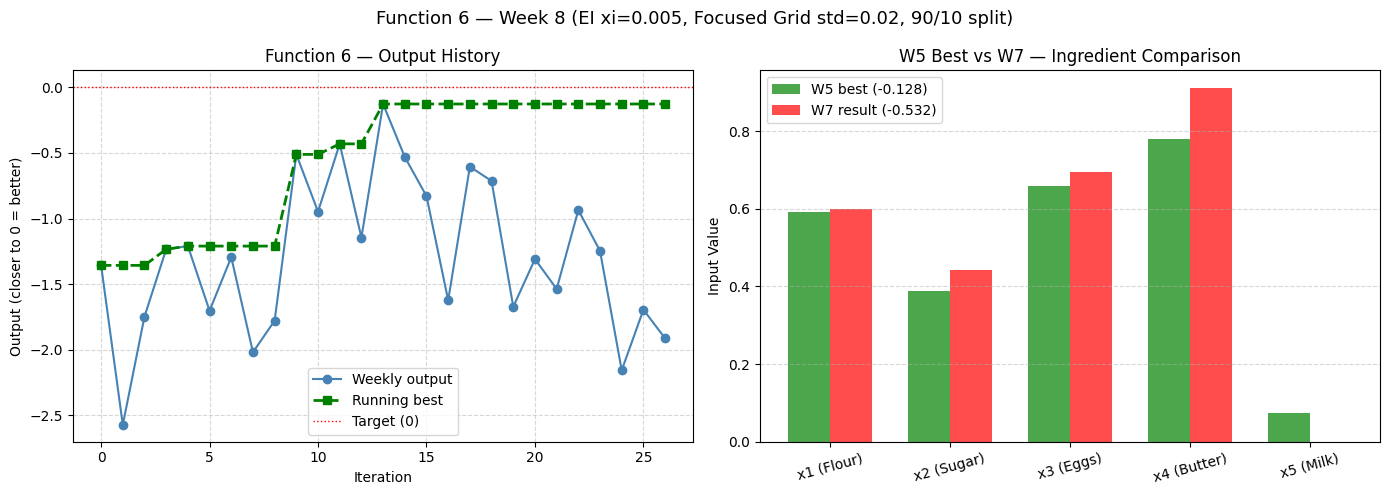

In [5]:
running_max = np.maximum.accumulate(Y_updated)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(Y_updated, marker='o', color='steelblue', linewidth=1.5, label='Weekly output')
axes[0].plot(running_max, marker='s', color='green', linewidth=2, linestyle='--', label='Running best')
axes[0].axhline(0, color='red', linestyle=':', linewidth=1, label='Target (0)')
axes[0].set_title('Function 6 — Output History')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Output (closer to 0 = better)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Show the W5 best ingredient profile vs W7 for comparison
ingredient_labels = ['x1 (Flour)', 'x2 (Sugar)', 'x3 (Eggs)', 'x4 (Butter)', 'x5 (Milk)']
x = np.arange(len(ingredient_labels))
width = 0.35
axes[1].bar(x - width/2, w5_best, width, label='W5 best (-0.128)', color='green', alpha=0.7)
axes[1].bar(x + width/2, X_w7_new_point, width, label='W7 result (-0.532)', color='red', alpha=0.7)
axes[1].set_title('W5 Best vs W7 — Ingredient Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(ingredient_labels, rotation=15)
axes[1].set_ylabel('Input Value')
axes[1].legend()
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Function 6 — Week 8 (EI xi=0.005, Focused Grid std=0.02, 90/10 split)', fontsize=13)
plt.tight_layout()
plt.show()